# The Rounding Tax — a quantitative teardown \U0001F52C
### Largest-remainder allocation · error-versus-capital · drag vs mean-zero noise

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Partial](https://img.shields.io/badge/Tradability-Partial-dab617?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The central
distinction is between a shortfall that **compounds** and one that **cancels**, because they
lead to opposite advice and are almost always quoted as one number.

> ⚠️ **Not investment advice.** Total-return closes from Yahoo! Finance pinned as-of the date in
> [`docs/results.md`](../docs/results.md).
>
> \U0001F4A1 **The `\U0001F4A1 In plain words` notes** translate each result back into intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))   # repo root (quantlab/ lives there)
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

In [2]:
from roundingtax import data, strategy as st

px = data.load_prices()
target = dict(data.TARGET)
names = [t for t in target if t in px.columns]
panel = px[names].dropna()
last = panel.iloc[-1]
print(f"as-of {data.AS_OF} | {len(panel):,} sessions, "
      f"{panel.index[0].date()} -> {panel.index[-1].date()}")
for t in names:
    print(f"  {t:6s} target {target[t]:>4.0%}   ${last[t]:8.2f} per share")
print(f"\none share of everything: ${st.one_share_cost(target, last):,.2f}")

as-of 2026-06-30 | 3,877 sessions, 2011-01-28 -> 2026-06-30
  SPY    target  40%   $  746.77 per share
  VXUS   target  20%   $   85.49 per share
  BND    target  25%   $   72.91 per share
  IJR    target   5%   $  148.31 per share
  VNQ    target   5%   $   96.43 per share
  GLD    target   5%   $  368.38 per share

one share of everything: $1,518.29


## Verdict, up front

| Axis | Stamp | Why |
|---|---|---|
| **Signal** | Weak | A **$3,000** account holding the 6-fund target could not place it: the achieved weights missed the plan by **5.4%** in total absolute terms on average, worst position off by 17.2%, and **0.6%** of the account sat in uninvested residue. Against a fractional-share portfolio running the identical plan, the tracking error was **0.28%/yr** over 15 years. Two numbers put that in proportion. One share of each fund costs $1,518 — the figure usually quoted — but the account that actually *hits* the target weights to within one percentage point is **$38,857**, an order of magnitude more, because owning one of everything gives you a portfolio whose weights are set by share prices rather than by your plan. |
| **Tradability** | Partial | But the shortfall is mostly **noise, not drag**, and the difference decides the advice. Over 15 years the whole-share portfolio compounded at +9.10% against the fractional ideal's +9.20% — a gap of **-0.10%/yr**, of which cash drag explains -0.03% and trading costs -0.01%, leaving -0.06% that is simply which way the dice fell. Allocation error is mean-zero — you are as likely to be overweight as under — so it produces tracking error without an expected cost; only the cash residue is one-directional. The fix that works is not fractional shares but **fewer funds**: cutting the target to its three largest positions dropped the allocation error from 5.4% to **3.4%**. |

> \U0001F4A1 **In plain words.** The constraint is real and the *cost* is smaller than it looks,
> because most of the shortfall is a coin flip rather than a leak.

## 1 · Hypotheses

- **H₁.** Whole-share rounding produces allocation error that scales roughly as 1/capital.
- **H₂.** It produces tracking error against a fractional-share twin running the same plan.
- **H₃ (the sharp one).** Most of the realised CAGR gap is **mean-zero noise**, not drag: the
  explainable components (cash residue, trading costs) account for a minority of it, and the
  residual changes sign across account sizes.
- **H₄.** Share *price level*, not returns, is the mechanism — provable by holding returns fixed
  and varying only the price.
- **H₅.** Reducing the number of funds helps more than fractional shares do.

## 2 · The allocator, checked by hand

In [3]:
# a case with an exact answer
p = pd.Series({"A": 100.0, "B": 50.0})
a = st.whole_share_allocation({"A": 0.5, "B": 0.5}, p, 1000.0)
print("clean case:", a["shares"], "cash", a["cash"])

# largest remainder against naive flooring
p2 = pd.Series({"A": 99.0, "B": 98.0, "C": 97.0})
t2 = {"A": 1 / 3, "B": 1 / 3, "C": 1 / 3}
a2 = st.whole_share_allocation(t2, p2, 1000.0)
naive = {t: float(np.floor(1000 / 3 / p2[t])) for t in t2}
naive_cash = 1000 - sum(naive[t] * p2[t] for t in t2)
print(f"\nnaive flooring:      {naive}, ${naive_cash:.2f} idle")
print(f"largest remainder:   {a2['shares']}, ${a2['cash']:.2f} idle")

clean case: {'A': 5.0, 'B': 10.0} cash 0.0

naive flooring:      {'A': 3.0, 'B': 3.0, 'C': 3.0}, $118.00 idle
largest remainder:   {'A': 3.0, 'B': 3.0, 'C': 4.0}, $21.00 idle


> \U0001F4A1 **In plain words.** This is the apportionment problem — the same arithmetic used to
> turn vote shares into whole parliamentary seats. Using the naive method would have made the
> whole-share case look worse than it is.

## 3 · The teardown

### 3.1 Error against capital, at several dates

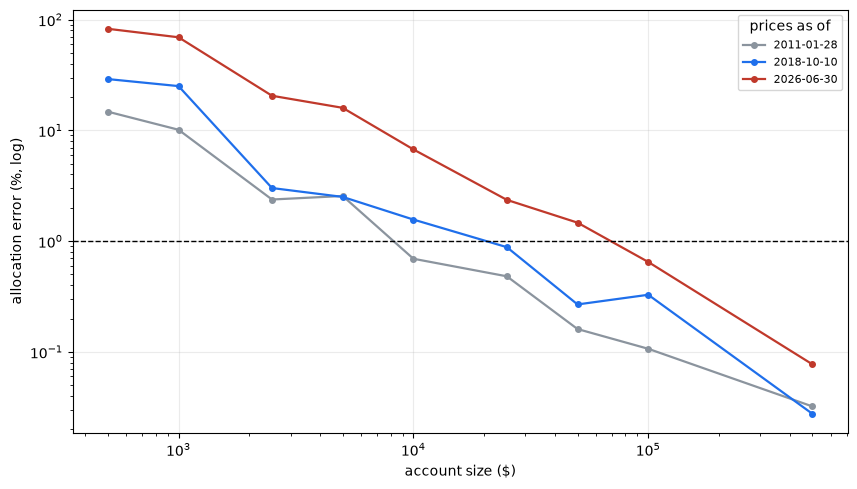

,one share of each,viable at 1pp,viable at 0.5pp
date,,,
2011-01-28,368.0000,"14,830.0000","23,033.0000"
2014-12-04,478.0000,"9,792.0000","27,632.0000"
2018-10-10,593.0000,"26,426.0000","40,071.0000"
2022-08-17,867.0000,"28,062.0000","56,418.0000"
2026-06-30,"1,518.0000","38,857.0000","156,357.0000"


In [4]:
fig, ax = plt.subplots(figsize=(10, 5.5))
for frac_i, colour in ((0.0, "#8b949e"), (0.5, "#1f6feb"), (1.0, "#c0392b")):
    i = int(frac_i * (len(panel) - 1))
    row = panel.iloc[i]
    ev = st.error_vs_capital(target, row)
    ax.loglog(ev.index, ev["l1_error"] * 100, "o-", lw=1.6, ms=4, color=colour,
              label=str(panel.index[i].date()))
ax.axhline(1, ls="--", color="k", lw=1)
ax.set_xlabel("account size ($)"); ax.set_ylabel("allocation error (%, log)")
ax.legend(fontsize=8, title="prices as of")
plt.show()
rows = []
for frac_i in (0.0, 0.25, 0.5, 0.75, 1.0):
    i = int(frac_i * (len(panel) - 1))
    row = panel.iloc[i]
    rows.append({"date": panel.index[i].date(),
                 "one share of each": st.one_share_cost(target, row),
                 "viable at 1pp": st.min_viable_capital(target, row, 0.01),
                 "viable at 0.5pp": st.min_viable_capital(target, row, 0.005)})
pd.DataFrame(rows).set_index("date").round(0)

### 3.2 The forward simulation, many account sizes

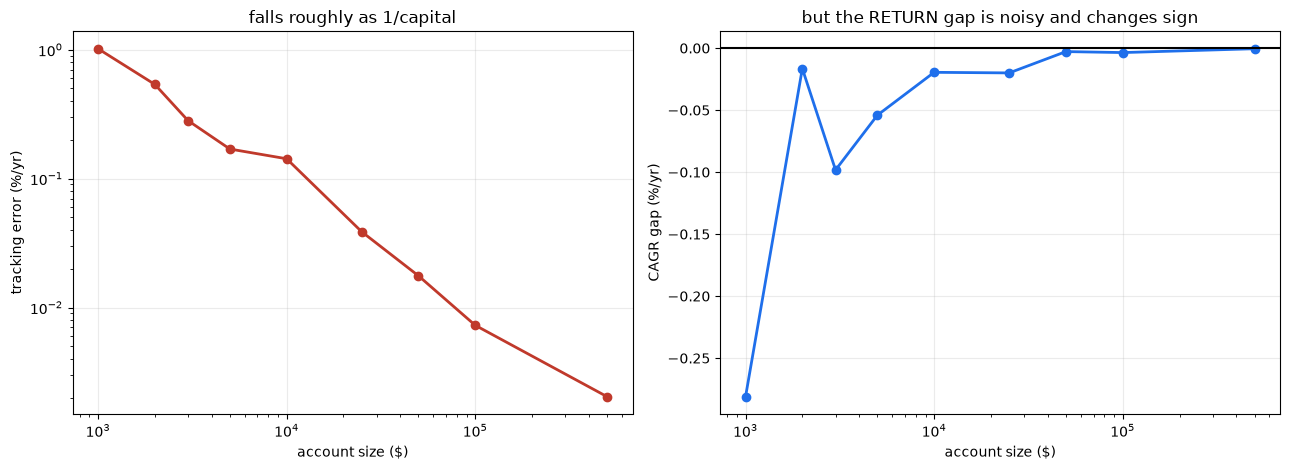

,tracking_error,cagr_gap,mean_l1_error,mean_cash_share
capital,,,,
1000,0.0102,-0.0028,0.1222,0.0147
2000,0.0054,-0.0002,0.0688,0.0065
3000,0.0028,-0.0010,0.0537,0.0058
5000,0.0017,-0.0005,0.0486,0.0033
10000,0.0014,-0.0002,0.0433,0.0023
25000,0.0004,-0.0002,0.0410,0.0006
50000,0.0002,-0.0000,0.0417,0.0002
100000,0.0001,-0.0000,0.0414,0.0001
500000,0.0000,-0.0000,0.0416,0.0000


In [5]:
cash_rate = px[data.CASH].pct_change().reindex(panel.index).fillna(0.0)
rows = []
for cap in (1000, 2000, 3000, 5000, 10_000, 25_000, 50_000, 100_000, 500_000):
    c = st.compare_to_ideal(panel, target, float(cap), cash_rate, cost_bps=5.0)
    rows.append({"capital": cap, **{k: c[k] for k in
                 ("tracking_error", "cagr_gap", "mean_l1_error", "mean_cash_share")}})
d = pd.DataFrame(rows).set_index("capital")
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
axes[0].loglog(d.index, d["tracking_error"] * 100, "o-", lw=2, color="#c0392b")
axes[0].set_xlabel("account size ($)"); axes[0].set_ylabel("tracking error (%/yr)")
axes[0].set_title("falls roughly as 1/capital")
axes[1].semilogx(d.index, d["cagr_gap"] * 100, "o-", lw=2, color="#1f6feb")
axes[1].axhline(0, color="k", lw=1.5)
axes[1].set_xlabel("account size ($)"); axes[1].set_ylabel("CAGR gap (%/yr)")
axes[1].set_title("but the RETURN gap is noisy and changes sign")
plt.tight_layout(); plt.show()
d.round(5)

> \U0001F4A1 **In plain words.** Two panels, two different stories. Tracking error is a clean
> monotone function of size — that is the constraint biting. The return gap wanders around zero
> — that is the constraint being mean-zero. Confusing the two is the mistake this study exists
> to prevent.

### 3.3 The decomposition

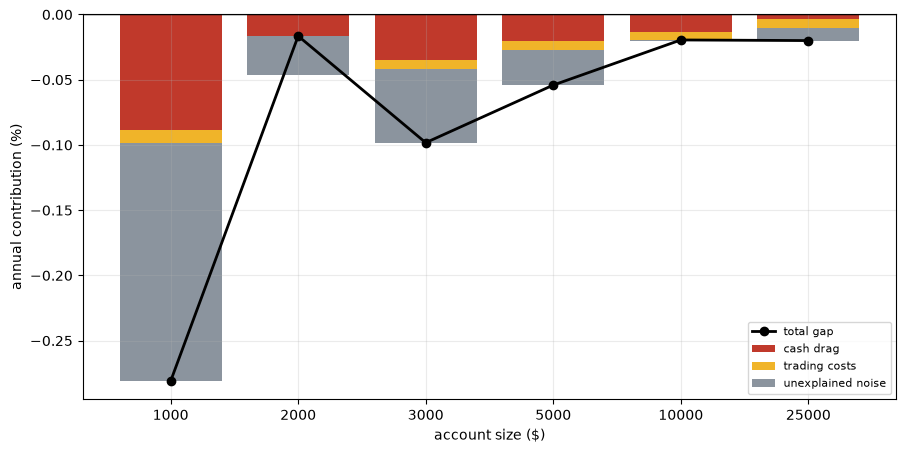

,total_gap,cash_drag,trading_costs,unexplained_noise
capital,,,,
1000,-0.0028,-0.0009,-0.0001,-0.0018
2000,-0.0002,-0.0004,-0.0001,0.0003
3000,-0.0010,-0.0003,-0.0001,-0.0006
5000,-0.0005,-0.0002,-0.0001,-0.0003
10000,-0.0002,-0.0001,-0.0001,0.0000
25000,-0.0002,-0.0000,-0.0001,-0.0001


In [6]:
rows = []
for cap in (1000, 2000, 3000, 5000, 10_000, 25_000):
    c = st.compare_to_ideal(panel, target, float(cap), cash_rate, cost_bps=5.0)
    dd = st.decompose_shortfall(c, 0.02, 0.06)
    rows.append({"capital": cap, **{k: dd[k] for k in
                 ("total_gap", "cash_drag", "trading_costs", "unexplained_noise")}})
d = pd.DataFrame(rows).set_index("capital")
fig, ax = plt.subplots(figsize=(10.5, 5))
bottom_pos = np.zeros(len(d))
for col, colour in (("cash_drag", "#c0392b"), ("trading_costs", "#f0b429"),
                    ("unexplained_noise", "#8b949e")):
    ax.bar([str(i) for i in d.index], d[col] * 100, bottom=bottom_pos * 100,
           color=colour, label=col.replace("_", " "))
    bottom_pos = bottom_pos + d[col]
ax.plot(range(len(d)), d["total_gap"] * 100, "ko-", lw=2, ms=6, label="total gap")
ax.axhline(0, color="k", lw=1)
ax.set_xlabel("account size ($)"); ax.set_ylabel("annual contribution (%)")
ax.legend(fontsize=8)
plt.show()
d.round(5)

### 3.4 The mechanism, isolated

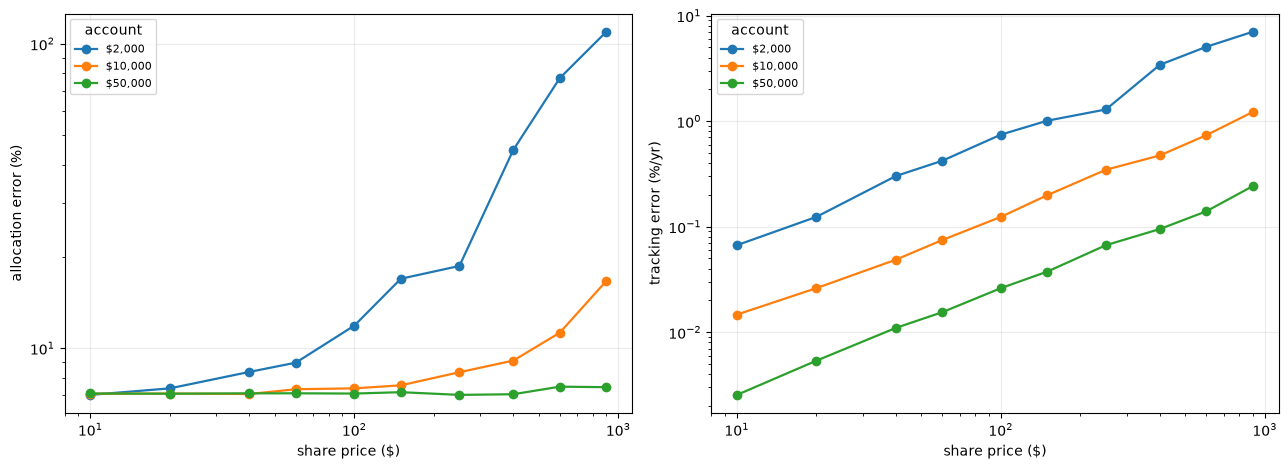

Identical return series in every point. Only the price LEVEL differs.


In [7]:
rows = []
for level in (10, 20, 40, 60, 100, 150, 250, 400, 600, 900):
    sp = st.synthetic_prices(n=2520, price_levels=(float(level),) * 6)
    tgt6 = {f"F{k}": 1 / 6 for k in range(6)}
    for cap in (2000, 10_000, 50_000):
        c = st.compare_to_ideal(sp, tgt6, float(cap))
        rows.append({"share_price": level, "capital": cap,
                     "mean_l1_error": c["mean_l1_error"],
                     "tracking_error": c["tracking_error"]})
d = pd.DataFrame(rows)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
for cap, g in d.groupby("capital"):
    axes[0].loglog(g["share_price"], g["mean_l1_error"] * 100, "o-", lw=1.6,
                   label=f"${cap:,}")
    axes[1].loglog(g["share_price"], g["tracking_error"] * 100, "o-", lw=1.6,
                   label=f"${cap:,}")
axes[0].set_xlabel("share price ($)"); axes[0].set_ylabel("allocation error (%)")
axes[1].set_xlabel("share price ($)"); axes[1].set_ylabel("tracking error (%/yr)")
for a in axes:
    a.legend(fontsize=8, title="account")
plt.tight_layout(); plt.show()
print("Identical return series in every point. Only the price LEVEL differs.")

### 3.5 Number of funds, and the diversification it costs

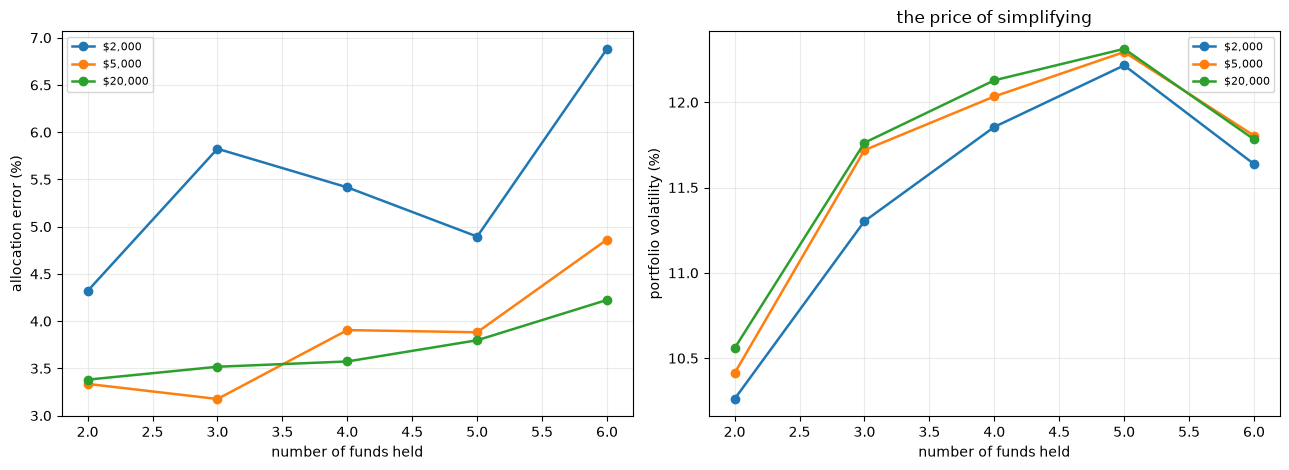

' funds  capital   cagr    vol  error\n     2     2000 0.0948 0.1026 0.0432\n     2     5000 0.0962 0.1041 0.0334\n     2    20000 0.0968 0.1056 0.0338\n     3     2000 0.0878 0.1130 0.0582\n     3     5000 0.0901 0.1172 0.0318\n     3    20000 0.0907 0.1176 0.0352\n     4     2000 0.0908 0.1186 0.0542\n     4     5000 0.0915 0.1203 0.0391\n     4    20000 0.0923 0.1213 0.0357\n     5     2000 0.0894 0.1222 0.0490\n     5     5000 0.0917 0.1229 0.0388\n     5    20000 0.0921 0.1231 0.0380\n     6     2000 0.0918 0.1164 0.0688\n     6     5000 0.0914 0.1180 0.0486\n     6    20000 0.0919 0.1178 0.0422'

In [8]:
esc_panel = px[[c for c in px.columns if c != data.CASH]].dropna()
rows = []
for keep in (2, 3, 4, 5, 6):
    tgt_k = st.fewer_funds_variant(target, keep)
    for cap in (2000, 5000, 20_000):
        s = st.rebalance_simulation(esc_panel, tgt_k, float(cap), cash_rate, cost_bps=5.0)
        if "cagr" not in s:
            continue
        rows.append({"funds": keep, "capital": cap, "cagr": s["cagr"], "vol": s["vol"],
                     "error": s["mean_l1_error"]})
d = pd.DataFrame(rows)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
for cap, g in d.groupby("capital"):
    axes[0].plot(g["funds"], g["error"] * 100, "o-", lw=1.8, label=f"${cap:,}")
axes[0].set_xlabel("number of funds held"); axes[0].set_ylabel("allocation error (%)")
axes[0].legend(fontsize=8)
for cap, g in d.groupby("capital"):
    axes[1].plot(g["funds"], g["vol"] * 100, "o-", lw=1.8, label=f"${cap:,}")
axes[1].set_xlabel("number of funds held"); axes[1].set_ylabel("portfolio volatility (%)")
axes[1].legend(fontsize=8)
axes[1].set_title("the price of simplifying")
plt.tight_layout(); plt.show()
d.round(4).to_string(index=False)

> \U0001F4A1 **In plain words.** The left panel is the benefit of holding fewer funds; the right
> panel is the cost. For a small account the left panel moves a lot and the right panel barely
> moves — which is the whole argument for a simple portfolio, made quantitatively rather than
> as a slogan.

### 3.6 No-trade bands

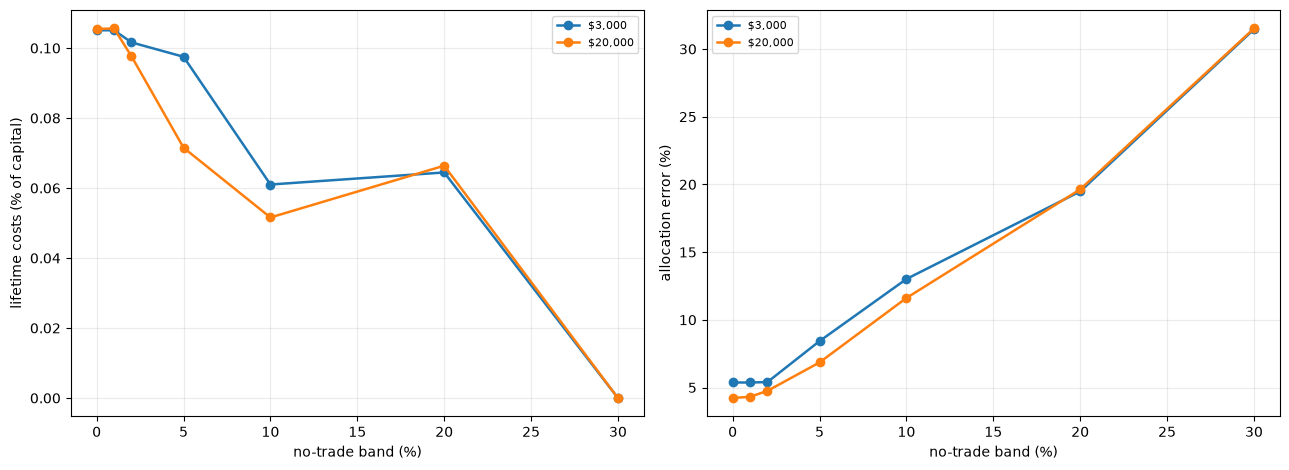

'  band  capital   cagr  rebalances  costs  error\n0.0000     3000 0.0910          15 0.0011 0.0537\n0.0000    20000 0.0919          15 0.0011 0.0422\n0.0100     3000 0.0910          15 0.0011 0.0537\n0.0100    20000 0.0920          14 0.0011 0.0432\n0.0200     3000 0.0907          12 0.0010 0.0540\n0.0200    20000 0.0921          12 0.0010 0.0475\n0.0500     3000 0.0934           5 0.0010 0.0843\n0.0500    20000 0.0920           5 0.0007 0.0685\n0.1000     3000 0.0947           2 0.0006 0.1301\n0.1000    20000 0.0950           2 0.0005 0.1161\n0.2000     3000 0.0984           1 0.0006 0.1948\n0.2000    20000 0.0991           1 0.0007 0.1963\n0.3000     3000 0.1024           0 0.0000 0.3145\n0.3000    20000 0.1033           0 0.0000 0.3152'

In [9]:
rows = []
for band in (0.0, 0.01, 0.02, 0.05, 0.10, 0.20, 0.30):
    for cap in (3000, 20_000):
        s = st.rebalance_simulation(panel, target, float(cap), cash_rate,
                                    cost_bps=5.0, band=band)
        rows.append({"band": band, "capital": cap, "cagr": s["cagr"],
                     "rebalances": s["n_rebalances"], "costs": s["cost_share"],
                     "error": s["mean_l1_error"]})
d = pd.DataFrame(rows)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
for cap, g in d.groupby("capital"):
    axes[0].plot(g["band"] * 100, g["costs"] * 100, "o-", lw=1.8, label=f"${cap:,}")
    axes[1].plot(g["band"] * 100, g["error"] * 100, "o-", lw=1.8, label=f"${cap:,}")
axes[0].set_xlabel("no-trade band (%)"); axes[0].set_ylabel("lifetime costs (% of capital)")
axes[1].set_xlabel("no-trade band (%)"); axes[1].set_ylabel("allocation error (%)")
for a in axes:
    a.legend(fontsize=8)
plt.tight_layout(); plt.show()
d.round(4).to_string(index=False)

## 4 · The verdict

In [10]:
cmp = st.compare_to_ideal(panel, target, 3000.0, cash_rate, cost_bps=5.0)
dec = st.decompose_shortfall(cmp, 0.02, 0.06)
esc = st.escape_table(esc_panel, target, 3000.0, cash_rate,
                      {data.CORE: data.CHEAP_CORE} if data.CHEAP_CORE in px.columns else None,
                      cost_bps=5.0)
alt = esc.drop(["whole shares, as specified", "fractional shares"], errors="ignore")
pd.DataFrame({
    "one share of everything": [st.one_share_cost(target, last)],
    "account needed for 1pp accuracy": [st.min_viable_capital(target, last)],
    "allocation error at $3,000": [cmp["mean_l1_error"]],
    "tracking error at $3,000": [cmp["tracking_error"]],
    "annual CAGR gap": [cmp["cagr_gap"]],
    "of which cash drag": [dec["cash_drag"]],
    "of which trading costs": [dec["trading_costs"]],
    "of which mean-zero noise": [dec["unexplained_noise"]],
    "best escape": [alt["mean_l1_error"].idxmin() if len(alt) else "none"],
    "its allocation error": [alt["mean_l1_error"].min() if len(alt) else np.nan],
}).T.rename(columns={0: "value"})

,value
one share of everything,"1,518.2908"
account needed for 1pp accuracy,"38,857.4181"
"allocation error at $3,000",0.0537
"tracking error at $3,000",0.0028
annual CAGR gap,-0.0010
of which cash drag,-0.0003
of which trading costs,-0.0001
of which mean-zero noise,-0.0006
best escape,two funds instead
its allocation error,0.0344


## 5 · Going further

- **Model regular contributions.** New cash directed at the most-underweight sleeve is a free
  rebalancing mechanism and would shrink almost every number here. Its omission is the largest
  in the study and it biases against small accounts.
- **Unadjusted prices.** Section 1 flags that adjusted closes understate historical share prices
  and therefore understate the constraint. Reconstructing true trade prices would strengthen the
  finding.
- **Integer programming.** `whole_share_allocation` uses largest remainder, which is a good
  heuristic and not the optimum. Solving the actual mixed-integer problem (Mansini & Speranza
  1999) would put a lower bound on the achievable error.
- **Compare against a target-date fund's expense ratio.** That is the decision a real small
  investor faces, and it is a straight comparison between the numbers here and a fee.